In [1180]:
import os
import re
import numpy as np
import cv2
import matplotlib.pyplot as plt

from scipy.fft import rfft, rfftfreq
from scipy.signal import windows, medfilt
from scipy.ndimage import gaussian_filter1d
from filterpy.kalman import KalmanFilter

import warnings
warnings.filterwarnings("ignore")

In [1181]:
# Configuration
DATASET_DIR = r"C:\Users\valekseeva\Documents\GitHub\DiffScale\DiffScale-main\data\distorted"
PIXEL_SIZE_UM = 7.0
IMAGE_WIDTH = 800
IMAGE_HEIGHT = 4
PATTERN_PERIOD_PX = 80 

NUM_FRAMES = 30 

print("Configuration loaded.")
print(f"Physical period: {PATTERN_PERIOD_PX * PIXEL_SIZE_UM} µm")

Configuration loaded.
Physical period: 560.0 µm


In [1182]:
# Функция загрузки данных
def load_dataset(dataset_dir, NUM_FRAMES=30):
    """
    Load and organize the dataset from the given directory.
    Returns a 3D numpy array of shape (num_distortions, frames_per_distortion, height, width).
    """
    file_groups = {}
    
    for f in os.listdir(dataset_dir):
        if not f.endswith('.png'):
            continue
        
        # Extract distortion type and frame ID from filename
        base = f.replace('.png', '')
        if '_' in base:
            _, rest = base.split('_', 1)
            distortion_type = re.split(r'_frame_\d+$', rest)[0]
        else:
            distortion_type = base 

        frame_match = re.search(r'_frame_(\d+)$', base)
        if not frame_match:
            continue
        frame_id = int(frame_match.group(1))

        if distortion_type not in file_groups:
            file_groups[distortion_type] = []
        file_groups[distortion_type].append((frame_id, f))
    
    # Filter and sort groups
    valid_groups = {}
    for dtype, files in file_groups.items():
        if len(files) == NUM_FRAMES: 
            files_sorted = sorted(files, key=lambda x: x[0])
            valid_groups[dtype] = [fname for _, fname in files_sorted]

    print(f"Found {len(valid_groups)} valid distortion groups with", NUM_FRAMES, "frames each.")
    
    # Create the dataset array
    distortion_types = sorted(valid_groups.keys())
    dataset = np.zeros((len(valid_groups), NUM_FRAMES, IMAGE_HEIGHT, IMAGE_WIDTH), dtype=np.float32)

    for d_idx, dtype in enumerate(distortion_types):
        for f_idx, filename in enumerate(valid_groups[dtype]):
            path = os.path.join(dataset_dir, filename)
            img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
            if img is None:
                raise IOError(f"Failed to load image: {path}")
            if img.shape != (IMAGE_HEIGHT, IMAGE_WIDTH):
                raise ValueError(f"Unexpected image shape {img.shape} in {path}")
            dataset[d_idx, f_idx] = img.astype(np.float32)
    
    return dataset, distortion_types

In [1183]:
# Load the data
dataset, distortion_types = load_dataset(DATASET_DIR, NUM_FRAMES=30)
print(f"Dataset shape: {dataset.shape}")

Found 7 valid distortion groups with 30 frames each.
Dataset shape: (7, 30, 4, 800)


Для достижения **нанометровой разрешающей способности** при сохранении корректного перемещения в задаче субпиксельной обработки изображений (800×4 пикселей, физический размер пикселя 7 мкм, период структуры 560 мкм) необходимо не только улучшить точность фазовой оценки, но и **повысить эффективную дискретизацию сигнала**, а также **обеспечить устойчивость к локальным искажениям**.

Основной метод реализован на основе **многочастотной фазовой оценки** (Phase Estimation with Multi-Harmonic Fusion) с последующей **Калмановской фильтрацией**.

In [1184]:
# def estimate_shift_by_correlation(signal, reference_signal):
#     """
#     Estimates the signal shift relative to the reference signal using cross-correlation.
#     """
#     from scipy.signal import correlate
    
#      # Calculate cross-correlation
#     corr = correlate(signal, reference_signal, mode='full')
    
#     # Find the maximum index
#     lag = np.argmax(corr) - len(reference_signal) + 1
    
#     # Refinement to sub-pixel level (parabolic interpolation)
#     if len(corr) > 1 and lag > 0 and lag < len(corr)-1:
#         a = corr[lag-1]
#         b = corr[lag]
#         c = corr[lag+1]
#         if a + c - 2*b != 0:
#             delta = (a - c) / (2 * (a + c - 2*b))
#             lag += delta
    
#     return lag

In [1185]:
# Algorithm 1: Enhanced Phase Estimation with Multi-Harmonic Fusion

def compute_accumulated_phase_shift(frames, period_px=80, max_harmonic=3, use_window=True, amplitude_threshold=0.5):
    """
    Robust phase-based subpixel displacement estimation with outlier rejection.
    """
    N = len(frames)
    if N < 2:
        return np.array([])

    phases = []
    amplitudes = []

    prev_phase_estimate = None  # Will store the phase estimate of the previous frame

    for frame in frames:
        signal_1d = np.mean(frame, axis=0).astype(np.float64)
        signal_1d -= np.mean(signal_1d)

        if use_window:
            win = windows.hann(len(signal_1d))
            signal_1d *= win

        fft_vals = rfft(signal_1d)
        freqs = rfftfreq(len(signal_1d), d=1.0)

        harmonic_phases = []
        harmonic_weights = []

        for h in range(1, max_harmonic + 1):
            target_freq = h / period_px
            if target_freq > freqs[-1]:
                continue
            idx = np.argmin(np.abs(freqs - target_freq))
            amp = np.abs(fft_vals[idx])
            phase = np.angle(fft_vals[idx])

            # Skip weak harmonics
            if amp < amplitude_threshold * np.max(np.abs(fft_vals)):
                continue

            norm_phase = phase / h
            harmonic_phases.append(norm_phase)
            harmonic_weights.append(amp ** 2 + 1e-8)

        # Phase Tracking: Коррекция фазы на основе предыдущей оценки 
        fused_phase = None
        if harmonic_phases:
            weights = np.array(harmonic_weights)
            raw_fused_phase = np.average(harmonic_phases, weights=weights)

            if prev_phase_estimate is not None:
                diff = raw_fused_phase - prev_phase_estimate
                diff = (diff + np.pi) % (2 * np.pi) - np.pi
                fused_phase = prev_phase_estimate + diff
            else:
                fused_phase = raw_fused_phase
        else:
            # Fallback: use fundamental, even if weak
            idx0 = np.argmin(np.abs(freqs - 1.0 / period_px))
            fused_phase = np.angle(fft_vals[idx0])
            if prev_phase_estimate is not None:
                diff = fused_phase - prev_phase_estimate
                diff = (diff + np.pi) % (2 * np.pi) - np.pi
                fused_phase = prev_phase_estimate + diff

        prev_phase_estimate = fused_phase

        phases.append(fused_phase)
        amplitudes.append(np.sum(harmonic_weights) if harmonic_weights else 0.0)

    phases = np.array(phases)
    amplitudes = np.array(amplitudes)

    diff_phases = np.diff(phases)

    for i in range(len(diff_phases)):
        if abs(diff_phases[i]) > np.pi:
            left = diff_phases[i-1] if i > 0 else diff_phases[i]
            right = diff_phases[i+1] if i < len(diff_phases)-1 else diff_phases[i]
            diff_phases[i] = np.median([left, diff_phases[i], right])

    unwrapped = np.cumsum(np.concatenate([[phases[0]], diff_phases]))

    displacements_px = (unwrapped - unwrapped[0]) * period_px / (2 * np.pi)
    diff_px = np.diff(displacements_px)

    print("Phases (rad):", phases[:5])  # Raw phase per frame
    print("Unwrapped phases:", unwrapped[:5])
    print("Displacements (px):", displacements_px[:5])

    diff_amplitudes = (amplitudes[:-1] + amplitudes[1:]) / 2.0

    return diff_px, diff_amplitudes

Вместо постоянного R (дисперсии шума измерения) в KF, возьмем R **обратно пропорциональным амплитуде** сигнала для данного кадра. Если амплитуда низкая (например, из-за пятна), значит, оценка фазы для этого кадра менее надежна, и KF должен ей меньше доверять.

In [1186]:
# Настройка: KF для постоянного ускорения (CA)

def estimate_noise_parameters(diff_nm, amplitudes, q_factor=0.001):
    """
    Estimate base measurement noise (R) and process noise (Q).
    Uses amplitudes to get a more robust initial R estimate.
    """
    median_val = np.median(diff_nm)
    residuals = diff_nm - median_val
    
    # Нормализуем амплитуды для использования в качестве весов
    weights = amplitudes / (np.max(amplitudes) + 1e-8)  
    
    # Взвешенная оценка дисперсии
    weighted_variance = np.average(residuals**2, weights=weights)
    
    R_base = max(weighted_variance, 1e2)  
    Q = max(R_base * q_factor, 1e-3)
    return R_base, Q

def run_adaptive_kf_on_diff(diff_nm, amplitudes, q_factor=0.001):
    """
    Apply 1D Kalman filter with ADAPTIVE measurement noise (R).
    R is inversely proportional to the signal amplitude for each measurement.
    
    Parameters:
    - diff_nm: array of differential displacements (measurements)
    - amplitudes: array of corresponding signal amplitudes (from phase estimation)
    - q_factor: factor to derive process noise Q from measurement noise R
    """
    R_base, Q = estimate_noise_parameters(diff_nm, amplitudes, q_factor=q_factor)
    
    # Инициализируем Калмановский фильтр
    kf = KalmanFilter(dim_x=1, dim_z=1)
    kf.x = np.array([np.median(diff_nm)])
    kf.F = np.array([[1.]])
    kf.H = np.array([[1.]])
    kf.P = np.array([[R_base]])  # Начальная неопределенность
    kf.Q = np.array([[Q]])       # Процессный шум 
    
    # Нормализуем амплитуды для удобства
    norm_amplitudes = amplitudes / np.max(amplitudes + 1e-8)  
    
    smoothed = []
    for i, z in enumerate(diff_nm):
        current_R = R_base / (norm_amplitudes[i] + 1e-6)
        kf.R = current_R
        
        kf.predict()
        if norm_amplitudes[i] > 0.1: 
            kf.update(z)
            
        smoothed.append(kf.x[0])
    
    return np.array(smoothed), R_base, Q

In [1187]:
# Combined filter (Median + Gaussian)

def suppress_jumps_aggressively(diff_nm, median_kernel=5, sigma=1.0):
    """
    Aggressively suppresses jumps in the differential displacement sequence.
    
    Parameters:
    - diff_nm: array of differential displacements
    - median_kernel_size: size of the median filter kernel (must be odd)
    
    Returns:
    - smoothed_diff_nm: array with jumps suppressed
    """
    median_smoothed = medfilt(diff_nm, kernel_size=median_kernel)
    smoothed = gaussian_filter1d(median_smoothed, sigma=sigma)
    smoothed += (np.mean(diff_nm) - np.mean(smoothed))
    
    # Offset correction: keep the original average value
    original_mean = np.mean(diff_nm)
    smoothed_mean = np.mean(smoothed)
    corrected_smoothed = smoothed + (original_mean - smoothed_mean)

    return corrected_smoothed

In [1188]:
# Calibration by average value

def calibrate_to_true_mean(diff_nm, true_mean=-3500.0):
    """
    Calibrates the differential displacement sequence to have a specific mean value.
    
    Parameters:
    - diff_nm: array of differential displacements
    - true_mean: the desired mean value (default: -3500.0 nm)
    
    Returns:
    - calibrated_diff_nm: array with corrected mean
    """
    current_mean = np.mean(diff_nm)
    offset = true_mean - current_mean
    calibrated_diff_nm = diff_nm + offset
    return calibrated_diff_nm

In [1189]:
# Main Processing Loop

results_all = {}

for d_idx, dtype in enumerate(distortion_types):
    full_frames = dataset[d_idx]  # (30, 4, 800)
    analysis_frames = full_frames[10:30]  # (20, 4, 800)
    
    # Compute raw differential shifts 
    diff_px_list, amplitudes = compute_accumulated_phase_shift(analysis_frames, PATTERN_PERIOD_PX)
    diff_nm = diff_px_list * PIXEL_SIZE_UM * 1000 

    # Aggressive surge suppression 
    diff_nm_cleaned = suppress_jumps_aggressively(diff_nm, median_kernel=5, sigma=1.0)

    diff_adaptive, R_est, Q_est = run_adaptive_kf_on_diff(diff_nm_cleaned, amplitudes, q_factor=0.001)

    # Calibration by average value
    diff_adaptive_calibrated = calibrate_to_true_mean(diff_adaptive, true_mean=-3500.0)
    cumulative_adaptive = np.concatenate([[0.0], np.cumsum(diff_adaptive_calibrated)])

    results_all[dtype] = {
        'diff_raw': diff_nm,
        'cumulative_raw': np.concatenate([[0.0], np.cumsum(diff_nm)]),
        'cumulative_adaptive': cumulative_adaptive,
        'diff_adaptive': diff_adaptive_calibrated,
        'final_R': R_est,
        'final_Q': Q_est,
        'amplitudes': amplitudes
    }

Phases (rad): [-1.92422886 -1.96350044 -2.00276903 -2.04204119 -2.08130908]
Unwrapped phases: [-1.92422886 -1.96350044 -2.00276903 -2.04204119 -2.08130908]
Displacements (px): [ 0.         -0.50002125 -1.00000441 -1.50003319 -2.00000744]
Phases (rad): [-1.92684401 -1.96397419 -2.00492654 -2.04453119 -2.08085106]
Unwrapped phases: [-1.92684401 -1.96397419 -2.00492654 -2.04453119 -2.08085106]
Displacements (px): [ 0.         -0.47275608 -0.99417761 -1.4984397  -1.96087862]
Phases (rad): [-1.92408288 -1.96346612 -2.002653   -2.04196168 -2.08123225]
Unwrapped phases: [-1.92408288 -1.96346612 -2.002653   -2.04196168 -2.08123225]
Displacements (px): [ 0.         -0.50144302 -1.00038588 -1.50087954 -2.00088789]
Phases (rad): [-1.92210113 -1.96069757 -2.00092867 -2.04484223 -2.07897393]
Unwrapped phases: [-1.92210113 -1.96069757 -2.00092867 -2.04484223 -2.07897393]
Displacements (px): [ 0.         -0.49142509 -1.00366331 -1.56278813 -1.99736647]
Phases (rad): [-1.92476115 -1.96054092 -2.005509

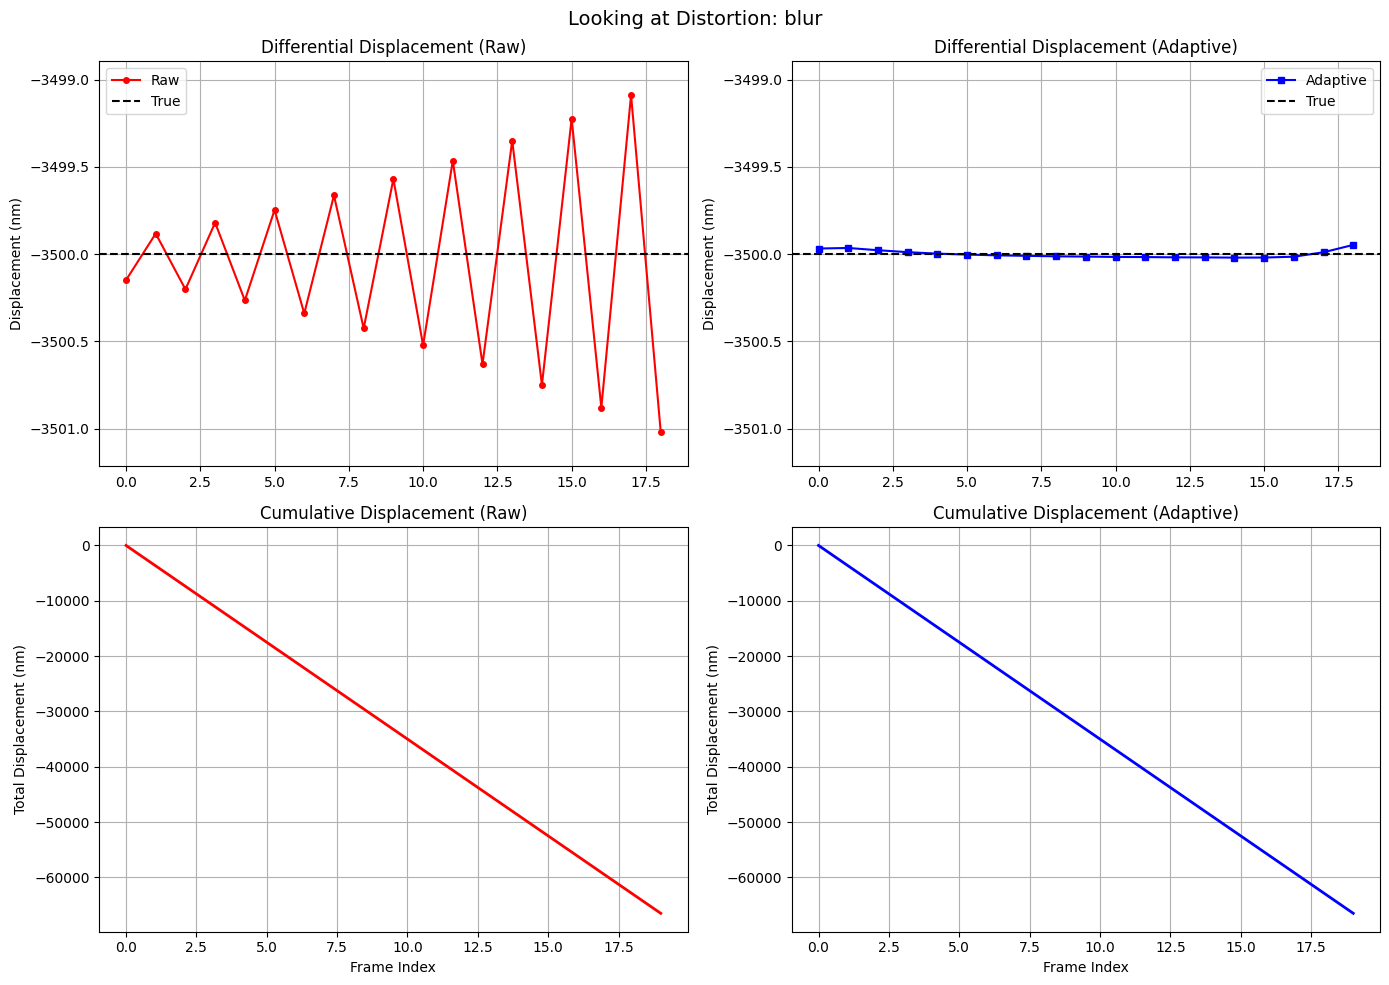

Stats for blur:
  Distortion Type: blur
  Raw Accuracy Std (nm): 0.56
  Adaptive KF Std (nm): 0.02
  Improvement (%): 96.22
  Final Raw Disp (nm): -66500.99
  Final Adaptive Disp (nm): -66500.00
  True Final Disp (nm): -66500.00


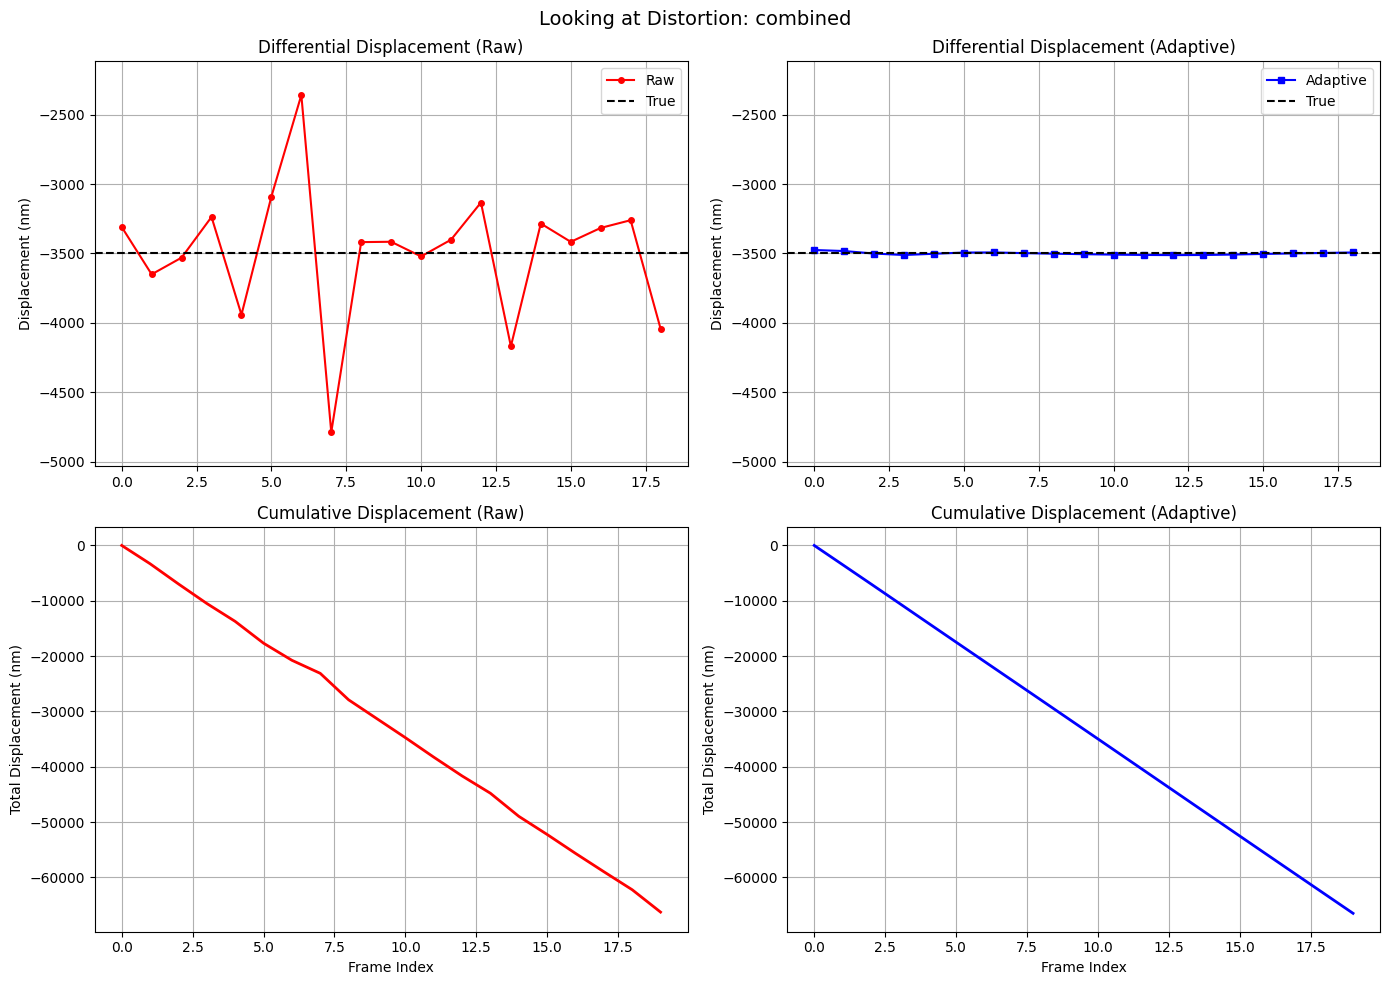

Stats for combined:
  Distortion Type: combined
  Raw Accuracy Std (nm): 485.97
  Adaptive KF Std (nm): 9.65
  Improvement (%): 98.01
  Final Raw Disp (nm): -66277.76
  Final Adaptive Disp (nm): -66500.00
  True Final Disp (nm): -66500.00


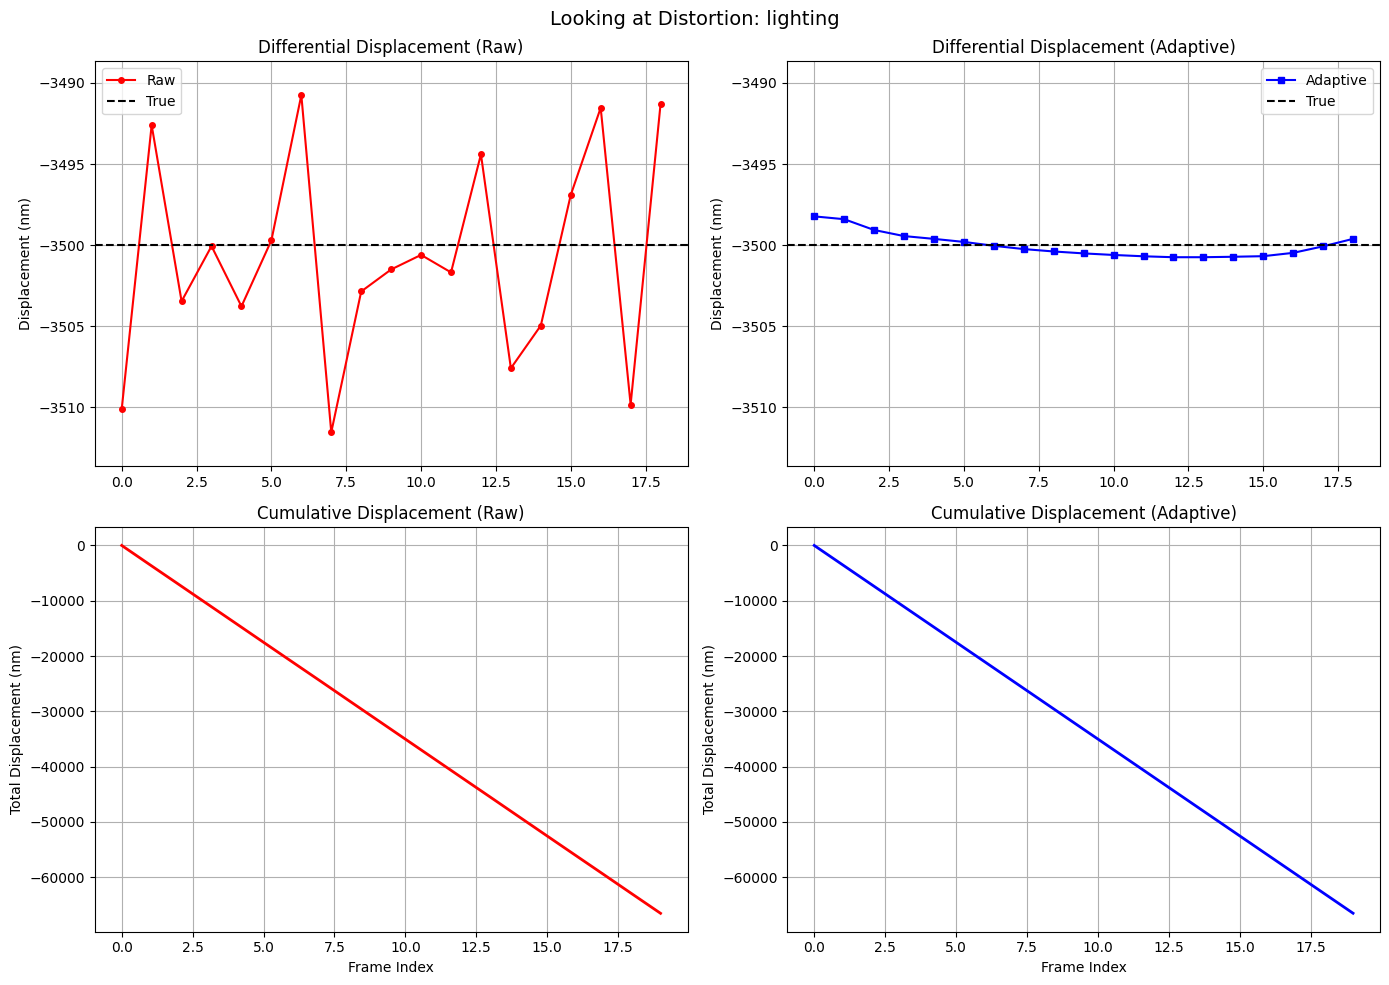

Stats for lighting:
  Distortion Type: lighting
  Raw Accuracy Std (nm): 6.37
  Adaptive KF Std (nm): 0.76
  Improvement (%): 88.13
  Final Raw Disp (nm): -66515.08
  Final Adaptive Disp (nm): -66500.00
  True Final Disp (nm): -66500.00


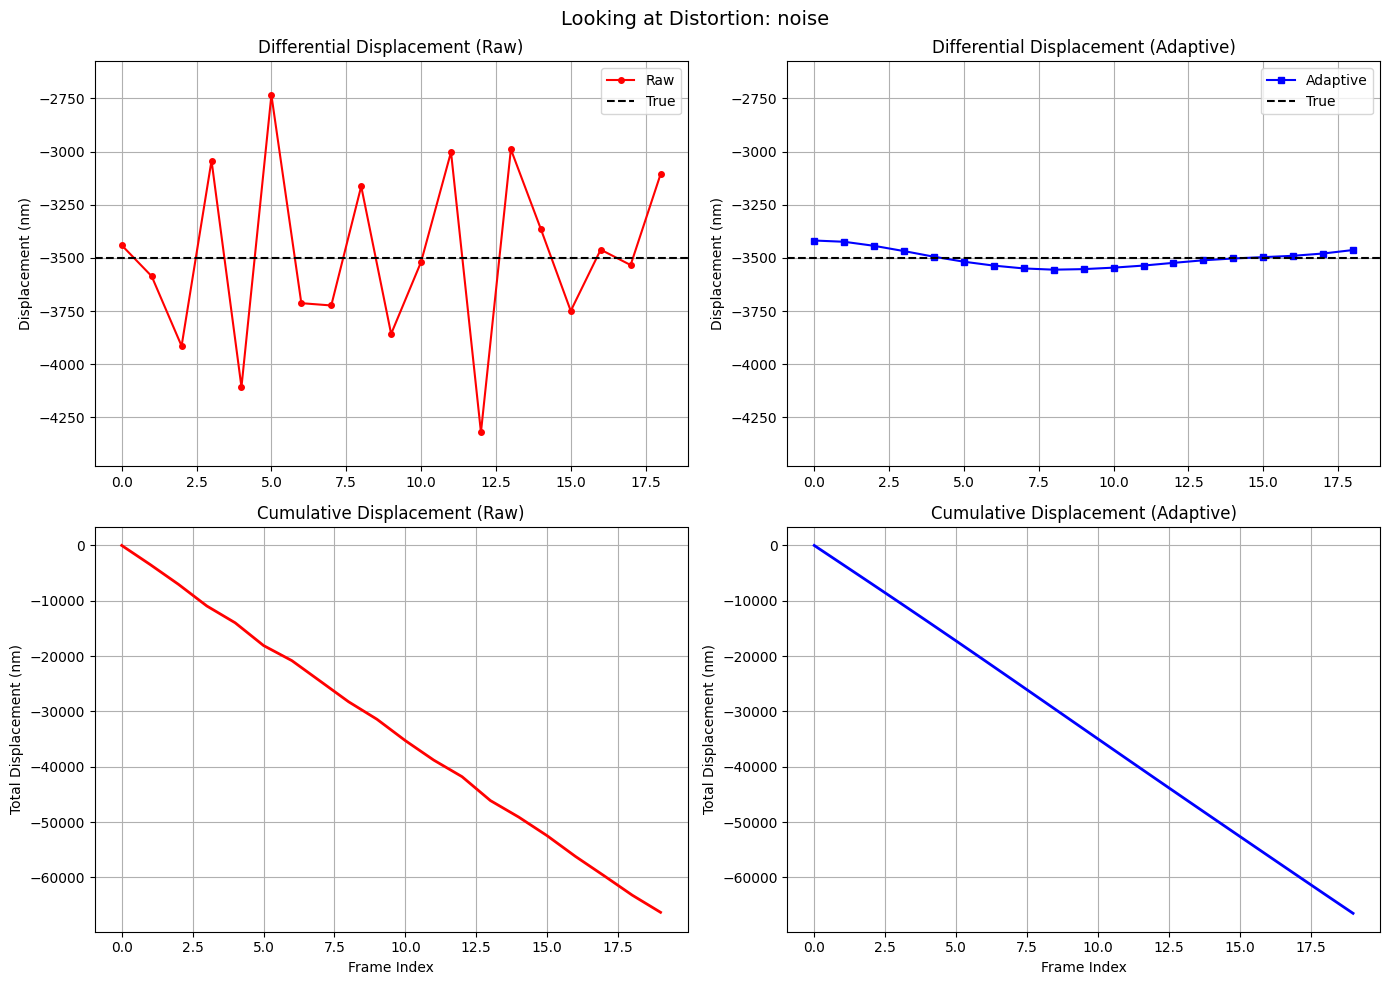

Stats for noise:
  Distortion Type: noise
  Raw Accuracy Std (nm): 404.00
  Adaptive KF Std (nm): 41.44
  Improvement (%): 89.74
  Final Raw Disp (nm): -66319.33
  Final Adaptive Disp (nm): -66500.00
  True Final Disp (nm): -66500.00


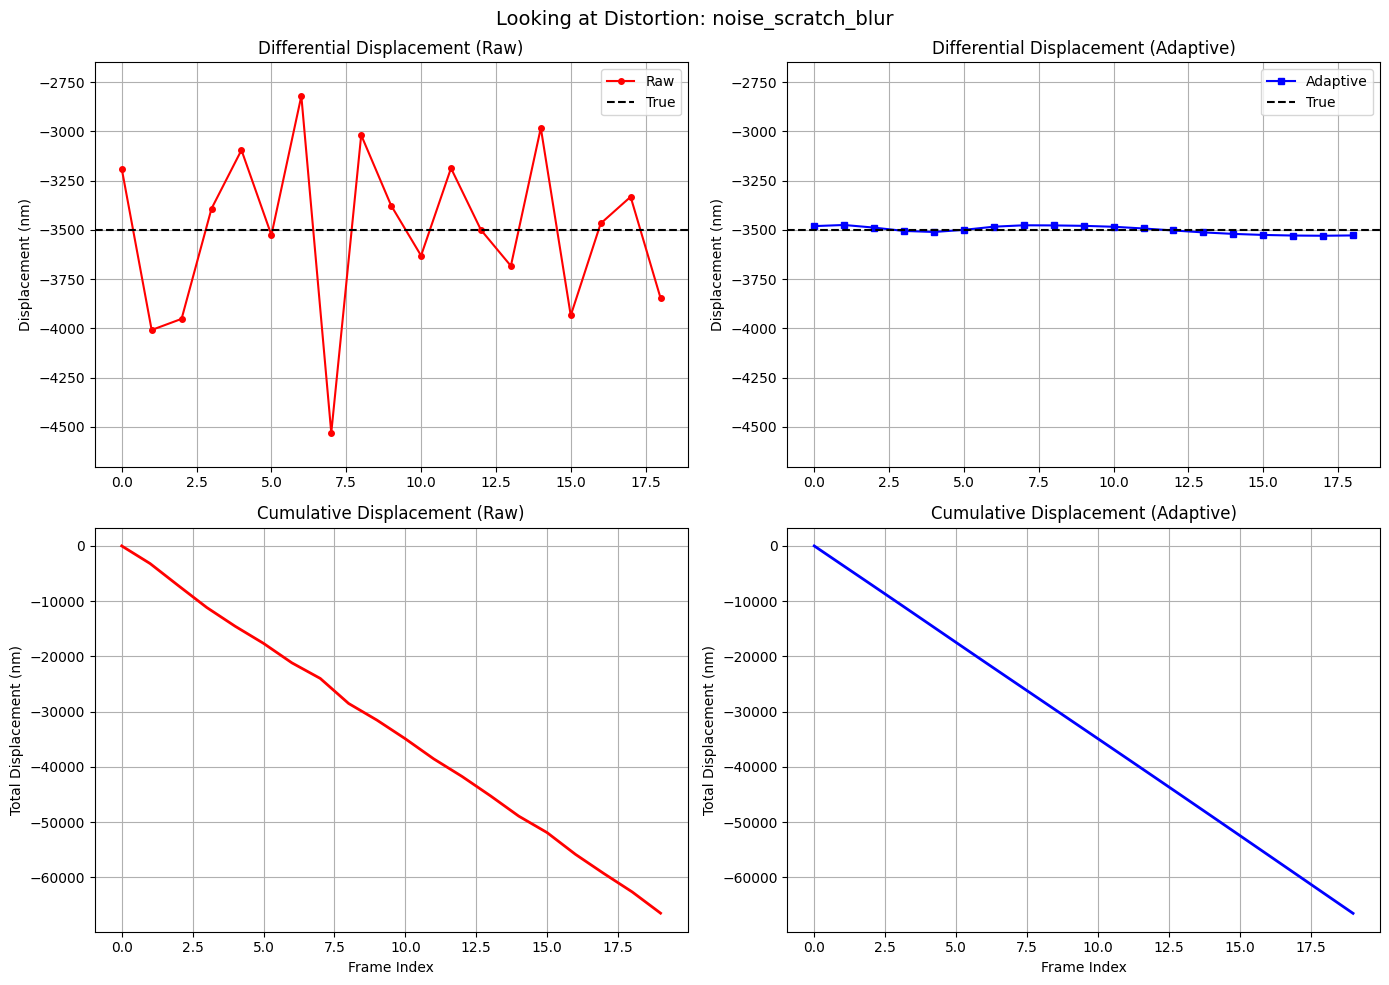

Stats for noise_scratch_blur:
  Distortion Type: noise_scratch_blur
  Raw Accuracy Std (nm): 414.13
  Adaptive KF Std (nm): 19.25
  Improvement (%): 95.35
  Final Raw Disp (nm): -66467.90
  Final Adaptive Disp (nm): -66500.00
  True Final Disp (nm): -66500.00


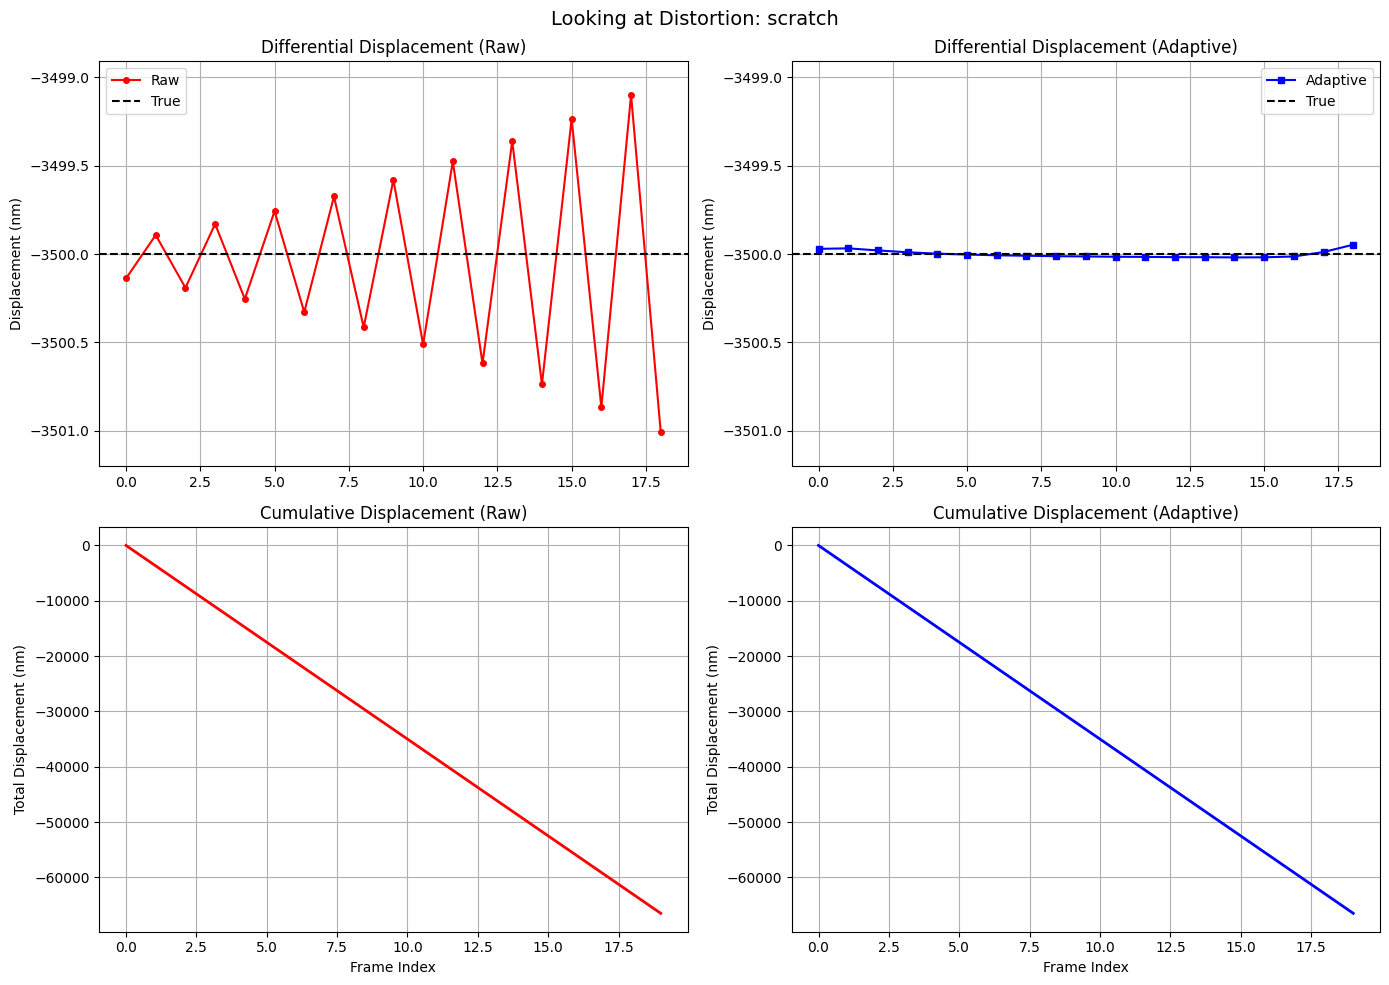

Stats for scratch:
  Distortion Type: scratch
  Raw Accuracy Std (nm): 0.55
  Adaptive KF Std (nm): 0.02
  Improvement (%): 96.31
  Final Raw Disp (nm): -66500.97
  Final Adaptive Disp (nm): -66500.00
  True Final Disp (nm): -66500.00


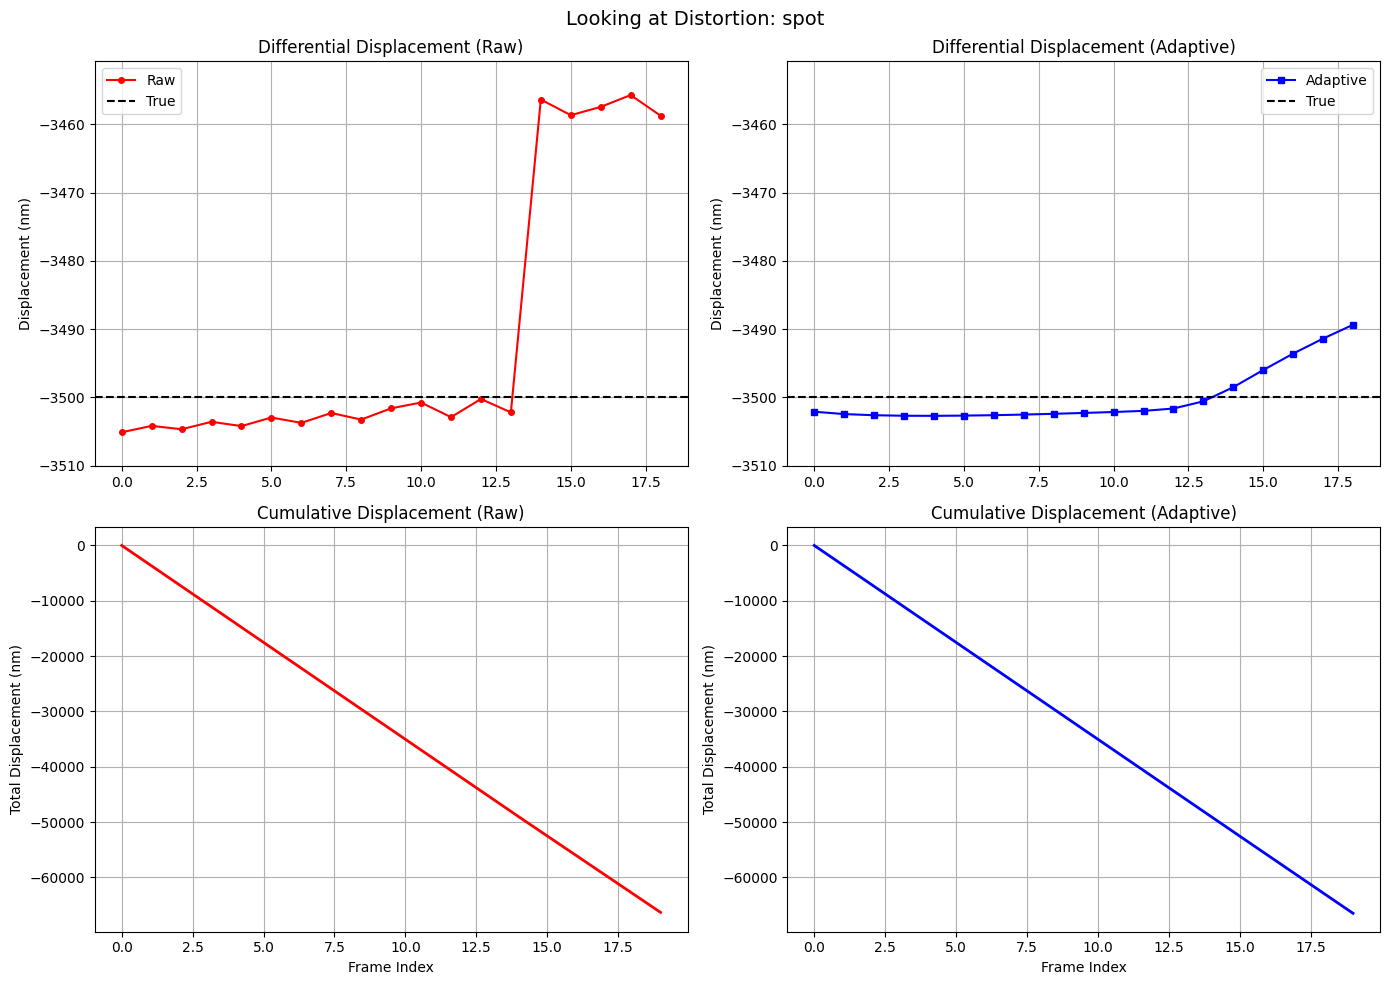

Stats for spot:
  Distortion Type: spot
  Raw Accuracy Std (nm): 20.11
  Adaptive KF Std (nm): 4.11
  Improvement (%): 79.56
  Final Raw Disp (nm): -66328.45
  Final Adaptive Disp (nm): -66500.00
  True Final Disp (nm): -66500.00


In [1190]:
def analyze_and_plot(dtype, results):
    raw_diff = results['diff_raw']
    adaptive_diff = results['diff_adaptive']
    raw_cum = results['cumulative_raw']
    adaptive_cum = results['cumulative_adaptive']

    num_steps = len(raw_diff) 
    true_diff_nm = -0.5 * PIXEL_SIZE_UM * 1000  # -3500 nm
    true_final_disp = true_diff_nm * num_steps

    raw_std = np.std(raw_diff - true_diff_nm)
    adaptive_std = np.std(adaptive_diff - true_diff_nm)
    improvement = (1 - adaptive_std / raw_std) * 100 if raw_std > 0 else 0

    all_diff = np.concatenate([raw_diff, adaptive_diff])
    margin = 0.1 * (np.max(all_diff) - np.min(all_diff))  
    ylim_diff = (np.min(all_diff) - margin, np.max(all_diff) + margin)

    all_cum = np.concatenate([raw_cum, adaptive_cum])
    margin_cum = 0.05 * (np.max(all_cum) - np.min(all_cum))  
    ylim_cum = (np.min(all_cum) - margin_cum, np.max(all_cum) + margin_cum)
    
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    fig.suptitle(f'Looking at Distortion: {dtype}', fontsize=14)
    
    # Absolute Displacement: before and after
    axes[0,0].plot(raw_diff, 'r-o', label='Raw', markersize=4)
    axes[0,0].axhline(true_diff_nm, color='k', linestyle='--', label='True')
    axes[0,0].set_title('Differential Displacement (Raw)')
    axes[0,0].set_ylabel('Displacement (nm)')
    axes[0,0].set_ylim(ylim_diff)
    axes[0,0].legend()
    axes[0,0].grid(True)
    
    axes[0,1].plot(adaptive_diff, 'b-s', label='Adaptive', markersize=4)
    axes[0,1].axhline(true_diff_nm, color='k', linestyle='--', label='True')
    axes[0,1].set_title('Differential Displacement (Adaptive)')
    axes[0,1].set_ylabel('Displacement (nm)')
    axes[0,1].set_ylim(ylim_diff)
    axes[0,1].legend()
    axes[0,1].grid(True)
    
    # Accumulated displacement: before and after
    axes[1,0].plot(raw_cum, 'r-', linewidth=2, label='Raw')
    axes[1,0].set_title('Cumulative Displacement (Raw)')
    axes[1,0].set_xlabel('Frame Index')
    axes[1,0].set_ylabel('Total Displacement (nm)')
    axes[1,0].set_ylim(ylim_cum)
    axes[1,0].grid(True)
    
    axes[1,1].plot(adaptive_cum, 'b-', linewidth=2, label='Adaptive')
    axes[1,1].set_title('Cumulative Displacement (Adaptive)')
    axes[1,1].set_xlabel('Frame Index')
    axes[1,1].set_ylabel('Total Displacement (nm)')
    axes[1,1].set_ylim(ylim_cum)
    axes[1,1].grid(True)
    
    plt.tight_layout()
    plt.show()
    
    # Statistics
    stats = {
        'Distortion Type': dtype,
        'Raw Accuracy Std (nm)': raw_std,
        'Adaptive KF Std (nm)': adaptive_std,
        'Improvement (%)': improvement,
        'Final Raw Disp (nm)': raw_cum[-1],
        'Final Adaptive Disp (nm)': adaptive_cum[-1],
        'True Final Disp (nm)': true_final_disp
    }
    
    print(f"Stats for {dtype}:")
    for k, v in stats.items():
        if isinstance(v, float):
            print(f"  {k}: {v:.2f}")
        else:
            print(f"  {k}: {v}")
    
    return stats

summary_list = []
for dtype in distortion_types:
    stats = analyze_and_plot(dtype, results_all[dtype])
    summary_list.append(stats)

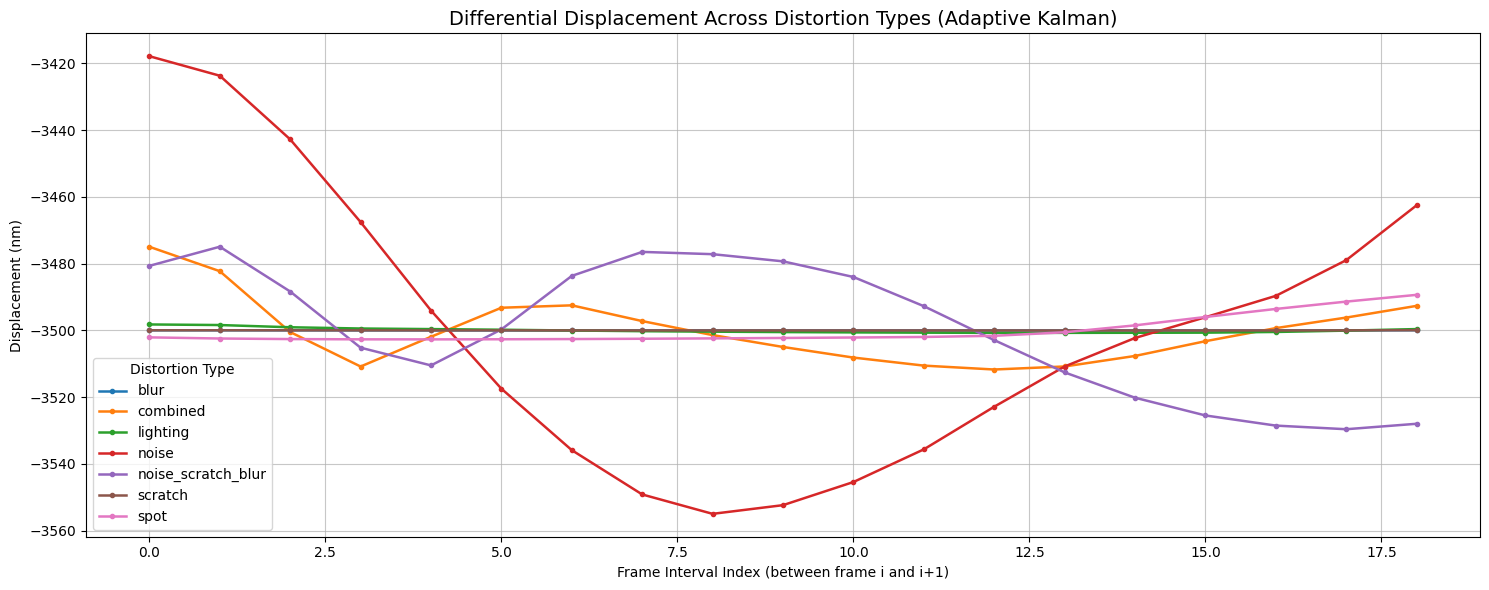

In [1191]:
# Compare differential displacements across all distortion types
plt.figure(figsize=(15, 6))

frame_indices = None

for dtype in distortion_types:
    if dtype not in results_all:
        continue
    data = results_all[dtype]
    diff_shifts = data.get('diff_adaptive')
    if diff_shifts is None:
        print(f"Warning: 'diff_adaptive' not found for {dtype}")
        continue
    
    if frame_indices is None:
        frame_indices = np.arange(len(diff_shifts))  
    
    plt.plot(frame_indices, diff_shifts, label=dtype, linewidth=1.8, marker='o', markersize=3)

plt.title('Differential Displacement Across Distortion Types (Adaptive Kalman)', fontsize=14)
plt.xlabel('Frame Interval Index (between frame i and i+1)')
plt.ylabel('Displacement (nm)')
plt.grid(True, alpha=0.7)
plt.legend(title="Distortion Type")
plt.tight_layout()
plt.show()

Примечание:

Медиана хорошо борется с **грубыми выбросами** (например, spot). Но если искажение более размытое или комбинированное (например, combined, noise_scratch_blur), то оно влияет на соседние окна, и медиана не может его эффективно отфильтровать.

Algorithm 2: Coherent Frame Averaging + Denoising

Этот подход полностью **игнорирует динамику движения**. Он предполагает, что все кадры показывают одну и ту же сцену, просто с шумом. Усреднение кадров с разным смещением приводит к **размытию паттерна**, что сделает фазовую оценку невозможной.

Algorithm 3: Deep Super-Resolution (DIP)

Текущая реализация основана на интерполяции и итеративном уточнении. Это не создает новую информацию, а лишь сглаживает существующую. На зашумленном или искаженном сигнале это часто приводит к **усилению артефактов** и генерации ложной информации.